In [30]:
import numpy as np
import matplotlib.pyplot as plt
import copy
import math
import pandas as pd
%matplotlib inline

In [31]:
url = "https://raw.githubusercontent.com/kaleko/CourseraML/refs/heads/master/ex2/data/ex2data1.txt"
df = pd.read_csv(url)
df.columns = ['Exam1', 'Exam2', 'Admitted']
df.head()

,Exam1,Exam2,Admitted
0,30.286711,43.894998,0
1,35.847409,72.902198,0
2,60.182599,86.308552,1
3,79.032736,75.344376,1
4,45.083277,56.316372,0


In [32]:
X_train = df[['Exam1', 'Exam2']]
y_train = df['Admitted']
print("First five elements in X_train are:\n", X_train[:5])
print("Type of X_train:",type(X_train))

First five elements in X_train are:
        Exam1      Exam2
0  30.286711  43.894998
1  35.847409  72.902198
2  60.182599  86.308552
3  79.032736  75.344376
4  45.083277  56.316372
Type of X_train: <class 'pandas.core.frame.DataFrame'>


In [33]:
print("First five elements in y_train are:\n", y_train[:5])
print("Type of y_train:",type(y_train))

First five elements in y_train are:
 0    0
1    0
2    1
3    1
4    0
Name: Admitted, dtype: int64
Type of y_train: <class 'pandas.core.series.Series'>


In [34]:
print ('The shape of X_train is: ' + str(X_train.shape))
print ('The shape of y_train is: ' + str(y_train.shape))
print ('We have m = %d training examples' % (len(y_train)))

The shape of X_train is: (99, 2)
The shape of y_train is: (99,)
We have m = 99 training examples


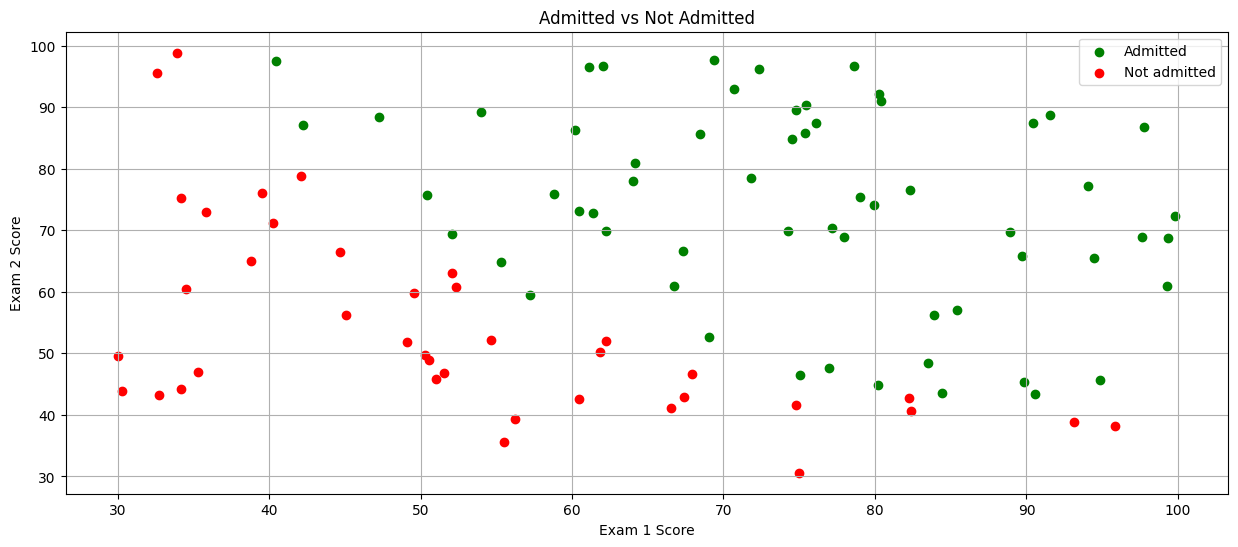

In [35]:
admitted = df[df['Admitted'] == 1]
not_admitted = df[df['Admitted'] == 0]

# Plotting
plt.figure(figsize=(15,6))
plt.scatter(admitted['Exam1'], admitted['Exam2'], c='green', label='Admitted')
plt.scatter(not_admitted['Exam1'], not_admitted['Exam2'], c='red', label='Not admitted')
plt.xlabel('Exam 1 Score')
plt.ylabel('Exam 2 Score')
plt.title('Admitted vs Not Admitted')
plt.legend()
plt.grid(True)
plt.show()

In [36]:
def sigmoid(z):
    
    g=1/(1+np.exp(-z))
       
    
    return g

value = 0

print (f"sigmoid({value}) = {sigmoid(value)}")

sigmoid(0) = 0.5


In [37]:

print("sigmoid([-1, 0, 1, 2]) = " + str(sigmoid(np.array([-1, 0, 1, 2]))))

sigmoid([-1, 0, 1, 2]) = [0.26894142 0.5        0.73105858 0.88079708]


# Cost function for logistic regression

In [38]:
def compute_cost(X, y, w, b, *argv):
    m,n=X.shape
    z=np.dot(X,w)+b
    f_wb=sigmoid(z)
    cost=-y*np.log(f_wb)-(1-y)*np.log(1-f_wb)
    total_cost=np.sum(cost)/m


    return total_cost

m, n = X_train.shape

# Compute and display cost with w and b initialized to zeros
initial_w = np.zeros(n)
initial_b = 0.
cost = compute_cost(X_train, y_train, initial_w, initial_b)
print('Cost at initial w and b (zeros): {:.3f}'.format(cost))

Cost at initial w and b (zeros): 0.693


In [39]:
test_w = np.array([0.2, 0.2])
test_b = -24.
cost = compute_cost(X_train, y_train, test_w, test_b)
print('Cost at test w and b (non-zeros): {:.3f}'.format(cost))

Cost at test w and b (non-zeros): 0.218


In [40]:
def compute_gradient(X, y, w, b, *argv):
    m, n = X.shape
    dj_dw = np.zeros(w.shape)
    dj_db = 0.

    for i in range(m):
        z_wb = 0
        for j in range(n):
            z_wb += X.iloc[i, j] * w[j]  # use iloc for pandas
        z_wb += b
        f_wb = sigmoid(z_wb)

        dj_db += (f_wb - y.iloc[i])

        for j in range(n):
            dj_dw[j] += (f_wb - y.iloc[i]) * X.iloc[i, j]

    dj_dw = dj_dw / m
    dj_db = dj_db / m

    return dj_db, dj_dw

dj_db, dj_dw = compute_gradient(X_train, y_train, initial_w, initial_b)
print(f'dj_db at initial w and b (zeros): {dj_db}')
print(f'dj_dw at initial w and b (zeros): {dj_dw.tolist()}')


dj_db at initial w and b (zeros): -0.10606060606060606
dj_dw at initial w and b (zeros): [-12.305388775165389, -11.770672393525663]


In [41]:
def gradient_descent(X, y, w_in, b_in, cost_function, gradient_function, alpha, num_iters, lambda_): 
    """
    Performs batch gradient descent to learn theta. Updates theta by taking 
    num_iters gradient steps with learning rate alpha
    
    Args:
      X :    (ndarray Shape (m, n) data, m examples by n features
      y :    (ndarray Shape (m,))  target value 
      w_in : (ndarray Shape (n,))  Initial values of parameters of the model
      b_in : (scalar)              Initial value of parameter of the model
      cost_function :              function to compute cost
      gradient_function :          function to compute gradient
      alpha : (float)              Learning rate
      num_iters : (int)            number of iterations to run gradient descent
      lambda_ : (scalar, float)    regularization constant
      
    Returns:
      w : (ndarray Shape (n,)) Updated values of parameters of the model after
          running gradient descent
      b : (scalar)                Updated value of parameter of the model after
          running gradient descent
    """
    
    # number of training examples
    m = len(X)
    
    # An array to store cost J and w's at each iteration primarily for graphing later
    J_history = []
    w_history = []
    
    for i in range(num_iters):

        # Calculate the gradient and update the parameters
        dj_db, dj_dw = gradient_function(X, y, w_in, b_in, lambda_)   

        # Update Parameters using w, b, alpha and gradient
        w_in = w_in - alpha * dj_dw               
        b_in = b_in - alpha * dj_db              
       
        # Save cost J at each iteration
        if i<100000:      # prevent resource exhaustion 
            cost =  cost_function(X, y, w_in, b_in, lambda_)
            J_history.append(cost)

        # Print cost every at intervals 10 times or as many iterations if < 10
        if i% math.ceil(num_iters/10) == 0 or i == (num_iters-1):
            w_history.append(w_in)
            print(f"Iteration {i:4}: Cost {float(J_history[-1]):8.2f}   ")
        
    return w_in, b_in, J_history, w_history #return w and J,w history for graphing


np.random.seed(1)
initial_w = 0.01 * (np.random.rand(2) - 0.5)
initial_b = -8

# Some gradient descent settings
iterations = 10000
alpha = 0.001

w,b, J_history,_ = gradient_descent(X_train ,y_train, initial_w, initial_b, 
                                   compute_cost, compute_gradient, alpha, iterations, 0)

Iteration    0: Cost     0.94   
Iteration 1000: Cost     0.30   
Iteration 2000: Cost     0.30   
Iteration 3000: Cost     0.30   
Iteration 4000: Cost     0.30   
Iteration 5000: Cost     0.30   
Iteration 6000: Cost     0.30   
Iteration 7000: Cost     0.30   
Iteration 8000: Cost     0.30   
Iteration 9000: Cost     0.30   
Iteration 9999: Cost     0.30   


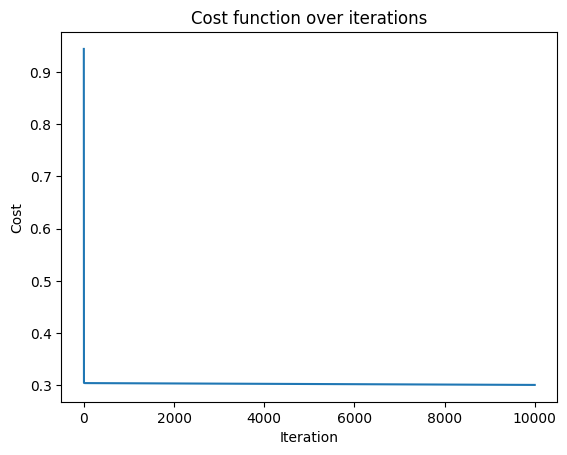

In [42]:
import matplotlib.pyplot as plt

plt.plot(J_history)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Cost function over iterations')
plt.show()


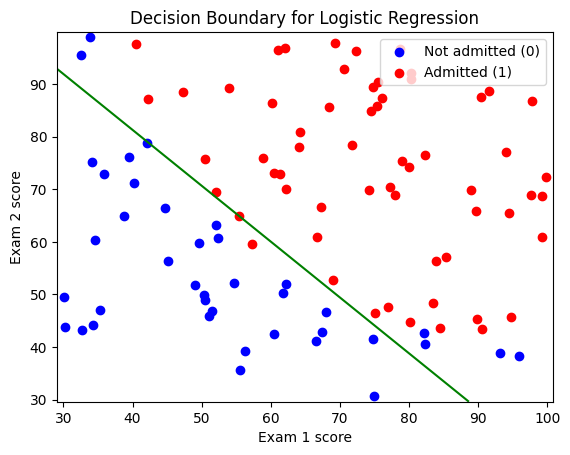

In [43]:
import numpy as np
import matplotlib.pyplot as plt



def plot_decision_boundary(w, b, X, y):
    # Scatter plot for class 0 and 1
    plt.scatter(X[y==0][:, 0], X[y==0][:, 1], color='blue', label='Not admitted (0)')
    plt.scatter(X[y==1][:, 0], X[y==1][:, 1], color='red', label='Admitted (1)')
    
    # Create grid to evaluate model
    x1_vals = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 200)
    x2_vals = np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 200)
    xx1, xx2 = np.meshgrid(x1_vals, x2_vals)
    grid = np.c_[xx1.ravel(), xx2.ravel()]
    
    # Compute the sigmoid prediction on the grid
    z = sigmoid(np.dot(grid, w) + b)
    z = z.reshape(xx1.shape)
    
    # Plot decision boundary where probability = 0.5
    plt.contour(xx1, xx2, z, levels=[0.5], colors='green')

    # Labels and legend
    plt.xlabel('Exam 1 score')
    plt.ylabel('Exam 2 score')
    plt.legend(loc='upper right')
    plt.title('Decision Boundary for Logistic Regression')

    plt.show()

X_np = X_train.values if hasattr(X_train, "values") else X_train
y_np = y_train.values if hasattr(y_train, "values") else y_train
plot_decision_boundary(w, b, X_np, y_np)


In [44]:
import numpy as np

# Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# UNQ_C4
# GRADED FUNCTION: predict
def predict(X, w, b): 
    """
    Predict whether the label is 0 or 1 using learned logistic
    regression parameters w
    
    Args:
      X : (ndarray Shape (m,n)) data, m examples by n features
      w : (ndarray Shape (n,))  values of parameters of the model      
      b : (scalar)              value of bias parameter of the model

    Returns:
      p : (ndarray (m,)) The predictions for X using a threshold at 0.5
    """
    m, n = X.shape   
    p = np.zeros(m)
   
    for i in range(m):   
        z_wb = 0
        for j in range(n): 
            z_wb += X[i, j] * w[j]
        z_wb += b
        f_wb = sigmoid(z_wb)
        p[i] = 1 if f_wb >= 0.5 else 0

    return p

# Test your predict code
np.random.seed(1)
tmp_w = np.random.randn(2)
tmp_b = 0.3    
tmp_X = np.random.randn(4, 2) - 0.5

tmp_p = predict(tmp_X, tmp_w, tmp_b)
print(f'Output of predict: shape {tmp_p.shape}, value {tmp_p}')


Output of predict: shape (4,), value [0. 1. 1. 1.]


In [45]:
p = predict(X_train.values, w, b)  # or X_train.to_numpy()
print('Train Accuracy: %f' % (np.mean(p == y_train.values) * 100))


Train Accuracy: 91.919192


# Regularized Logistic Regression

In [46]:
X_train = df[['Exam1', 'Exam2']]
y_train = df['Admitted']

# print X_train
print("X_train:", X_train[:5])
print("Type of X_train:",type(X_train))

# print y_train
print("y_train:", y_train[:5])
print("Type of y_train:",type(y_train))

X_train:        Exam1      Exam2
0  30.286711  43.894998
1  35.847409  72.902198
2  60.182599  86.308552
3  79.032736  75.344376
4  45.083277  56.316372
Type of X_train: <class 'pandas.core.frame.DataFrame'>
y_train: 0    0
1    0
2    1
3    1
4    0
Name: Admitted, dtype: int64
Type of y_train: <class 'pandas.core.series.Series'>


In [47]:
print ('The shape of X_train is: ' + str(X_train.shape))
print ('The shape of y_train is: ' + str(y_train.shape))
print ('We have m = %d training examples' % (len(y_train)))

The shape of X_train is: (99, 2)
The shape of y_train is: (99,)
We have m = 99 training examples


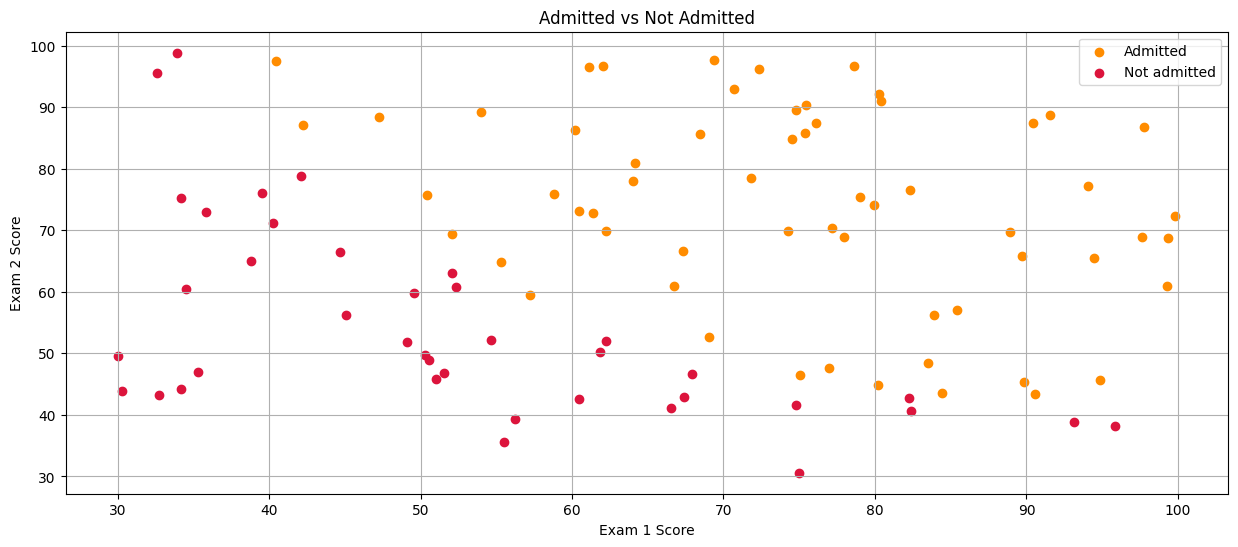

In [48]:
# Plotting
plt.figure(figsize=(15,6))
plt.scatter(admitted['Exam1'], admitted['Exam2'], c="darkorange", label='Admitted')
plt.scatter(not_admitted['Exam1'], not_admitted['Exam2'], c='crimson', label='Not admitted')
plt.xlabel('Exam 1 Score')
plt.ylabel('Exam 2 Score')
plt.title('Admitted vs Not Admitted')
plt.legend()
plt.grid(True)
plt.show()

In [49]:
def map_feature(x1, x2, degree=6):
    """
    Maps the two input features to polynomial features up to the given degree.

    Returns a new feature array with more features, comprising of 
    x1, x2, x1^2, x1*x2, x2^2, ..., x1^degree, x1^(degree-1)*x2, ..., x2^degree

    Args:
      x1, x2: array-like, shape (m, )

    Returns:
      out: A numpy array of shape (m, number of new features)
    """
    import numpy as np
    if x1.ndim > 0:
        x1 = x1[:, np.newaxis]
    if x2.ndim > 0:
        x2 = x2[:, np.newaxis]

    out = np.ones_like(x1)
    for i in range(1, degree + 1):
        for j in range(i + 1):
            term = (x1 ** (i - j)) * (x2 ** j)
            out = np.hstack((out, term))
    return out


In [50]:
mapped_X = map_feature(X_train.values[:, 0], X_train.values[:, 1])
print("Shape after feature mapping:", mapped_X.shape)


Shape after feature mapping: (99, 28)


In [51]:
print("X_train[0]:", X_train.iloc[0].values)  # get the values as a NumPy array
print("mapped X_train[0]:", mapped_X[0])      # mapped_X is already a NumPy array


X_train[0]: [30.28671077 43.89499752]
mapped X_train[0]: [1.00000000e+00 3.02867108e+01 4.38949975e+01 9.17284849e+02
 1.32943509e+03 1.92677081e+03 2.77815409e+04 4.02642162e+04
 5.83555502e+04 8.45755998e+04 8.41411494e+05 1.21947067e+06
 1.76739767e+06 2.56151673e+06 3.71244575e+06 2.54835866e+07
 3.69337555e+07 5.35286620e+07 7.75799163e+07 1.12437771e+08
 1.62957797e+08 7.71814016e+08 1.11860197e+09 1.62120710e+09
 2.34964049e+09 3.40537024e+09 4.93545566e+09 7.15303209e+09]


In [52]:
def compute_cost_reg(X, y, w, b, lambda_=1):
    m, n = X.shape

    # Cost without regularization
    cost_without_reg = compute_cost(X, y, w, b)

    # Regularization term (exclude bias b)
    reg_cost = (lambda_ / (2 * m)) * np.sum(w ** 2)

    total_cost = cost_without_reg + reg_cost
    return total_cost


np.random.seed(0)
X_train = pd.DataFrame(np.random.rand(100, 2) * 2 - 1, columns=['Feature1', 'Feature2'])
y_train = (X_train['Feature1']**2 + X_train['Feature2']**2 < 0.8).astype(int)  # Circle boundary

# --- Feature Mapping ---
X_mapped = map_feature(X_train.values[:, 0], X_train.values[:, 1])

# --- Initial Parameters ---
np.random.seed(1)
initial_w = np.random.rand(X_mapped.shape[1]) - 0.5
initial_b = 0.5
lambda_ = 0.5

# --- Compute Regularized Cost ---
cost = compute_cost_reg(X_mapped, y_train.values, initial_w, initial_b, lambda_)
print("✅ Regularized cost:", cost)

✅ Regularized cost: 0.6207650571286774


In [53]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

def map_feature(x1, x2, degree=6):
    if x1.ndim == 1:
        x1 = x1[:, np.newaxis]
    if x2.ndim == 1:
        x2 = x2[:, np.newaxis]
    out = np.ones((x1.shape[0], 1))
    for i in range(1, degree + 1):
        for j in range(i + 1):
            new_feature = (x1 ** (i - j)) * (x2 ** j)
            out = np.hstack((out, new_feature))
    return out

def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

def compute_cost_reg(X, y, w, b, lambda_):
    m = X.shape[0]
    z = np.dot(X, w) + b
    h = sigmoid(z)
    epsilon = 1e-15
    cost = (-1 / m) * (np.dot(y, np.log(h + epsilon)) + np.dot((1 - y), np.log(1 - h + epsilon)))
    reg_term = (lambda_ / (2 * m)) * np.sum(w[1:] ** 2)  # exclude bias
    return cost + reg_term

def compute_gradient_reg(X, y, w, b, lambda_):
    m, n = X.shape
    z = np.dot(X, w) + b
    h = sigmoid(z)
    error = h - y
    dj_dw = (1 / m) * np.dot(X.T, error)
    dj_db = (1 / m) * np.sum(error)
    dj_dw[1:] += (lambda_ / m) * w[1:]  # regularize all but bias
    return dj_db, dj_dw

def gradient_descent(X, y, w_in, b_in, cost_func, grad_func, alpha, num_iters, lambda_):
    w = w_in.copy()
    b = b_in
    J_history = []

    for i in range(num_iters):
        dj_db, dj_dw = grad_func(X, y, w, b, lambda_)
        w -= alpha * dj_dw
        b -= alpha * dj_db
        if i % 1000 == 0 or i == num_iters - 1:
            cost = cost_func(X, y, w, b, lambda_)
            J_history.append(cost)
            print(f"Iteration {i}: Cost {cost}")
            if np.isnan(cost) or np.isinf(cost):
                print("Cost is NaN or Inf, stopping early.")
                break
    return w, b, J_history, None

# Assume df is your DataFrame with Exam1, Exam2 and Admitted columns
X_train = df[['Exam1', 'Exam2']]
y_train = df['Admitted'].values

X_mapped = map_feature(X_train.iloc[:, 0].values, X_train.iloc[:, 1].values)

scaler = StandardScaler()
X_mapped = scaler.fit_transform(X_mapped)

np.random.seed(1)
initial_w = np.random.rand(X_mapped.shape[1]) - 0.5
initial_b = 0.5
lambda_ = 0.01
iterations = 10000
alpha = 0.01

dj_db, dj_dw = compute_gradient_reg(X_mapped, y_train, initial_w, initial_b, lambda_)
print(f"dj_db: {dj_db}")
print(f"First few elements of regularized dj_dw:\n {dj_dw[:4].tolist()}")

w, b, J_history, _ = gradient_descent(X_mapped, y_train, initial_w, initial_b, 
                                      compute_cost_reg, compute_gradient_reg,
                                      alpha, iterations, lambda_)


dj_db: -0.0052999266346793195
First few elements of regularized dj_dw:
 [0.0, -0.29449480219273816, -0.5743662500226783, -0.2701320765864452]
Iteration 0: Cost 1.5319127025348354
Iteration 1000: Cost 0.25845196514099406
Iteration 2000: Cost 0.21474484058768312
Iteration 3000: Cost 0.19031415872958735
Iteration 4000: Cost 0.1740014732824321
Iteration 5000: Cost 0.16201319026908523
Iteration 6000: Cost 0.15265784804713967
Iteration 7000: Cost 0.14505318942877596
Iteration 8000: Cost 0.1386875959173874
Iteration 9000: Cost 0.1332406090721405
Iteration 9999: Cost 0.1285038417061699


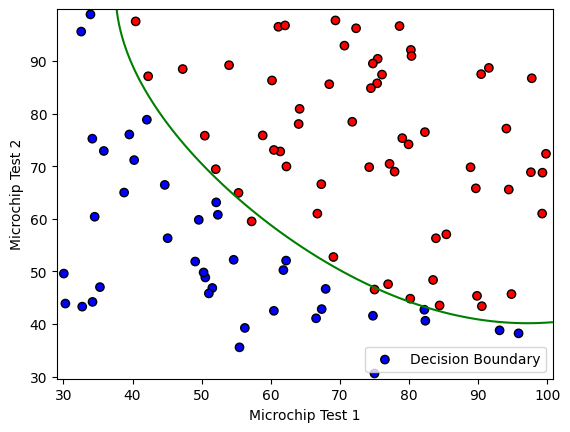

In [54]:

def plot_decision_boundary(w, b, X_orig, y, degree=6):
    x_min, x_max = X_orig[:, 0].min() - 1, X_orig[:, 0].max() + 1
    y_min, y_max = X_orig[:, 1].min() - 1, X_orig[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.linspace(x_min, x_max, 200),
                           np.linspace(y_min, y_max, 200))
    grid_points = np.c_[xx1.ravel(), xx2.ravel()]
    
    # Map features of grid points to polynomial features
    mapped_points = map_feature(grid_points[:, 0], grid_points[:, 1], degree)
    
    # Don't forget to scale grid points with the same scaler used for training
    mapped_points_scaled = scaler.transform(mapped_points)
    
    z = sigmoid(np.dot(mapped_points_scaled, w) + b)
    z = z.reshape(xx1.shape)
    
    plt.contour(xx1, xx2, z, levels=[0.5], colors='g')
    plt.scatter(X_orig[:, 0], X_orig[:, 1], c=y, cmap='bwr', edgecolors='k')
    plt.xlabel('Microchip Test 1')
    plt.ylabel('Microchip Test 2')
    plt.legend(['Decision Boundary', 'y=0', 'y=1'])
    plt.show()

plot_decision_boundary(w, b, X_train.values, y_train, degree=6)



In [55]:
p = predict(X_mapped, w, b)

print('Train Accuracy: %f'%(np.mean(p == y_train) * 100))

Train Accuracy: 97.979798
